In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'bright', 'vpedre'])
from classy import Class

import os
os.chdir('../')
import python.vp_utils as utils
from pathlib import Path
parameters_sim = utils.parameters_sim

In [2]:
base_path = Path('~/nerding/gravitomagnetic/output_cosma').expanduser()

models = ['lcdm', 'frhs', 'ndgp']
surveys = ['LSST', 'Euclid']
experiments = ['Planck', 'SO']

pars_lcdm = utils.build_cosmo_params_from_file(base_path / "lcdm/parameters-usedvalues")
pars_frhs = utils.build_cosmo_params_from_file(base_path / "frhs/parameters-usedvalues")
pars_ndgp = utils.build_cosmo_params_from_file(base_path / "ndgp/parameters-usedvalues")

# Cosmological parameters
params_base = {
    'output': 'tCl,sCl,lCl,mPk',
    'A_s': 2.1e-9,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'l_switch_limber': 50,
    'l_max_scalars': 10000
}

params_lcdm = params_base | {
    'h': pars_lcdm['h'],
    'Omega_cdm': pars_lcdm['Omega_m'] - pars_lcdm['Omega_b'],
    'Omega_b': pars_lcdm['Omega_b'],
}

params_frhs = params_base | {
    'h': pars_frhs['h'],
    'Omega_cdm': pars_frhs['Omega_m'] - pars_frhs['Omega_b'],
    'Omega_b': pars_frhs['Omega_b'],
}

params_ndgp = params_base | {
    'h': pars_ndgp['h'],
    'Omega_cdm': pars_ndgp['Omega_m'] - pars_ndgp['Omega_b'],
    'Omega_b': pars_ndgp['Omega_b'],
}

# Find C_ell_TT from CLASS for the different models
CLASS = {}
C_ell_TT = {}
ells = {}

for m in models:
    CLASS[m] = Class()
    CLASS[m].set(params_base)
    CLASS[m].compute()

    c_ell_unlensed = CLASS[m].raw_cl(10000)   # unlensed spectrum
    # cl_lensed = CLASS[m].lensed_cl(10000)  # lensed spectrum

    ells[m] = c_ell_unlensed['ell']
    C_ell_TT[m] = c_ell_unlensed['tt']  # unlensed tt power spectrum

In [21]:
ell_grid = np.logspace(2,4,40)

ell_idx = np.round(ell_grid).astype(int)

In [22]:
C_ell_TT[m][ell_idx]

array([2.23392842e-13, 2.02444354e-13, 1.85013423e-13, 1.68476978e-13,
       1.52645103e-13, 1.34656489e-13, 1.13960786e-13, 9.07718382e-14,
       6.73120579e-14, 4.44280126e-14, 2.51572694e-14, 1.31006108e-14,
       8.38082951e-15, 8.06511102e-15, 7.90182724e-15, 5.65895710e-15,
       3.44696515e-15, 3.29356130e-15, 3.00667499e-15, 1.31689775e-15,
       8.19660476e-16, 6.39769768e-16, 3.36241874e-16, 2.42949743e-16,
       1.13049609e-16, 5.19753647e-17, 3.03806999e-17, 1.38445371e-17,
       5.87449421e-18, 1.93225811e-18, 5.52020604e-19, 1.61538490e-19,
       3.67847515e-20, 7.04828696e-21, 1.30738460e-21, 3.34938607e-22,
       1.27593111e-22, 5.77636219e-23, 2.73918834e-23, 1.30022806e-23])

In [15]:
ell_grid

array([  100.        ,   112.53355826,   126.63801735,   142.51026703,
         160.37187438,   180.47217668,   203.09176209,   228.54638641,
         257.19138091,   289.42661247,   325.70206557,   366.52412371,
         412.46263829,   464.15888336,   522.33450743,   587.80160723,
         661.47406412,   744.38030133,   837.67764007,   942.66845512,
        1060.81835514,  1193.77664171,  1343.3993326 ,  1511.77507062,
        1701.25427985,  1914.48197617,  2154.43469003,  2424.46201708,
        2728.33337649,  3070.29062976,  3455.10729459,  3888.15518031,
        4375.47937507,  4923.88263171,  5541.02033001,  6235.50734127,
        7017.0382867 ,  7896.5228685 ,  8886.23816274, 10000.        ])

In [16]:
ells['lcdm']

array([    0,     1,     2, ...,  9998,  9999, 10000], shape=(10001,))

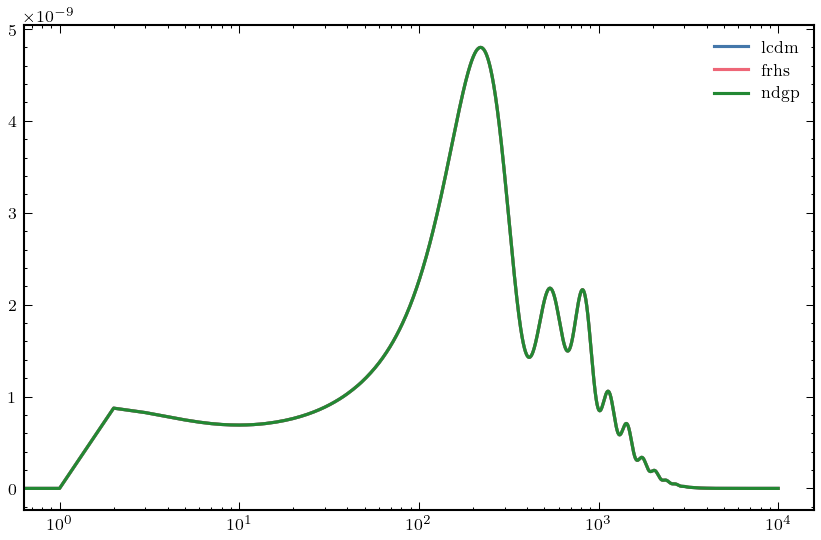

In [8]:
fig, ax = plt.subplots()
for m in models:
    ax.semilogx(ells[m], ells[m]*(ells[m]+1)*C_ell_TT[m], label=m)

ax.legend()